# Deep Learning Capstone: Handwritten Digit Classification

            ## 1. Learning objectives

            - Build a leakage-safe end-to-end image classifier
- Compare a linear baseline with tuned MLPs
- Evaluate errors on an untouched test set

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Classify 8-by-8 handwritten digits; success is held-out accuracy plus interpretable class-level error counts.

            ## 4. Real-world use cases

            - Document digit recognition
- Educational image pipelines
- Model comparison under CPU constraints

            ## 5. Core intuition in simple language

            Begin with a strong linear baseline, add nonlinear hidden features only if validation evidence supports them, then freeze the choice for test evaluation.

## 6. Mathematical foundation

            $$\mathbf{h}=\phi(\mathbf{X}\mathbf{W}+\mathbf{b}).$$

            **Every symbol:**

            - $\mathbf{X}$ is a batch of inputs.
- $\mathbf{W}$ is a learned weight matrix.
- $\mathbf{b}$ is a learned bias vector.
- $\phi$ is an activation function.
- $\mathbf{h}$ is the resulting representation.

            **Why the equation is needed:** Without the activation, stacked linear layers collapse to one linear transformation; the activation enables nonlinear patterns.

            **Small numerical example:** For x=[1,2], w=[.5,-.25], and b=.1, z=1(.5)+2(-.25)+.1=.1; ReLU(z)=.1.

            **Connection to Python:** torch.relu(X @ W + b) implements the equation while autograd records the operations.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

A transparent logits-to-accuracy calculation checks output semantics before model training.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def accuracy_from_logits(logits,target):
    return float((logits.argmax(axis=1)==target).mean())

example_logits=np.array([[2.,1.],[.2,.8]])
print("Manual accuracy:",accuracy_from_logits(example_logits,np.array([0,1])))

Manual accuracy: 1.0


## 10. Implementation using a standard library

Scikit-learn supplies the baseline and split/scaling tools; PyTorch supplies the MLP and training loop.

## 11. Dataset loading and exploration

The bundled Digits dataset has 1,797 grayscale 8-by-8 images and ten balanced classes.

## 12. Data preprocessing

Stratified development/test and train/validation splits occur before StandardScaler fitting.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Dataset/missing: (1797, 64) 0
Baseline accuracy: 0.972 best width/accuracy: 128 0.931
Selected MLP diagnostics: {'input_shape': (1077, 64), 'intermediate_shape': (1077, 128), 'output_shape': (1077, 10), 'trainable_parameters': 9610, 'final_training_loss': 0.1973, 'final_validation_loss': 0.22, 'validation_accuracy': 0.931}
Held-out test accuracy: 0.928


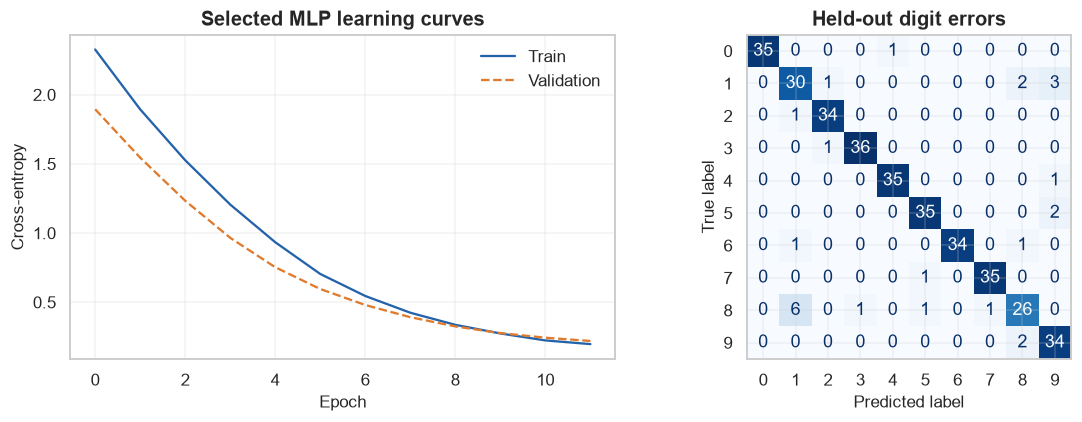

In [3]:
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits=load_digits()
X_development,X_test,y_development,y_test=train_test_split(digits.data,digits.target,test_size=.2,stratify=digits.target,random_state=RANDOM_SEED)
X_train,X_validation,y_train,y_validation=train_test_split(X_development,y_development,test_size=.25,stratify=y_development,random_state=RANDOM_SEED)
scaler=StandardScaler(); X_train_s=scaler.fit_transform(X_train); X_validation_s=scaler.transform(X_validation)
baseline=LogisticRegression(max_iter=1000,random_state=RANDOM_SEED).fit(X_train_s,y_train)
baseline_accuracy=baseline.score(X_validation_s,y_validation)

def fit_mlp(width):
    model=nn.Sequential(nn.Linear(64,width),nn.ReLU(),nn.Dropout(.2),nn.Linear(width,10))
    optimizer=torch.optim.Adam(model.parameters(),lr=.01); loss_fn=nn.CrossEntropyLoss()
    Xt=torch.tensor(X_train_s,dtype=torch.float32); yt=torch.tensor(y_train,dtype=torch.long)
    Xv=torch.tensor(X_validation_s,dtype=torch.float32); yv=torch.tensor(y_validation,dtype=torch.long)
    train_history=[]; validation_history=[]
    for _ in range(12):
        model.train(); optimizer.zero_grad(); logits=model(Xt); loss=loss_fn(logits,yt); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad(): val_logits=model(Xv); val_loss=loss_fn(val_logits,yv)
        train_history.append(loss.item()); validation_history.append(val_loss.item())
    return model,train_history,validation_history,float((val_logits.argmax(1)==yv).float().mean())

candidates={}
for width in [32,64,128]:
    candidates[width]=fit_mlp(width)
best_width=max(candidates,key=lambda value:candidates[value][3])
best_model,train_losses,validation_losses,best_validation_accuracy=candidates[best_width]
print("Dataset/missing:",digits.data.shape,int(np.isnan(digits.data).sum()))
print("Baseline accuracy:",round(baseline_accuracy,3),"best width/accuracy:",best_width,round(best_validation_accuracy,3))
best_model.eval()
with torch.no_grad():
    diagnostic_input=torch.tensor(X_train_s,dtype=torch.float32)
    diagnostic_hidden=best_model[1](best_model[0](diagnostic_input))
    diagnostic_output=best_model(diagnostic_input)
print("Selected MLP diagnostics:", {
    "input_shape": tuple(diagnostic_input.shape),
    "intermediate_shape": tuple(diagnostic_hidden.shape),
    "output_shape": tuple(diagnostic_output.shape),
    "trainable_parameters": sum(p.numel() for p in best_model.parameters()),
    "final_training_loss": round(train_losses[-1], 4),
    "final_validation_loss": round(validation_losses[-1], 4),
    "validation_accuracy": round(best_validation_accuracy, 3),
})

final_scaler=StandardScaler(); X_development_s=final_scaler.fit_transform(X_development); X_test_s=final_scaler.transform(X_test)
final_model=nn.Sequential(nn.Linear(64,best_width),nn.ReLU(),nn.Dropout(.2),nn.Linear(best_width,10))
optimizer=torch.optim.Adam(final_model.parameters(),lr=.01); loss_fn=nn.CrossEntropyLoss()
Xd=torch.tensor(X_development_s,dtype=torch.float32); yd=torch.tensor(y_development,dtype=torch.long)
for _ in range(12):
    final_model.train(); optimizer.zero_grad(); loss=loss_fn(final_model(Xd),yd); loss.backward(); optimizer.step()
final_model.eval()
with torch.no_grad(): test_prediction=final_model(torch.tensor(X_test_s,dtype=torch.float32)).argmax(1).numpy()
test_accuracy=accuracy_score(y_test,test_prediction)
print("Held-out test accuracy:",round(test_accuracy,3))
figure,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(train_losses,label="Train",color=COURSE_COLORS["blue"]); axes[0].plot(validation_losses,label="Validation",color=COURSE_COLORS["orange"],linestyle="--")
axes[0].set(title="Selected MLP learning curves",xlabel="Epoch",ylabel="Cross-entropy"); axes[0].legend()
ConfusionMatrixDisplay.from_predictions(y_test,test_prediction,cmap="Blues",colorbar=False,ax=axes[1]); axes[1].set_title("Held-out digit errors")
figure.tight_layout(); plt.show()

**How to interpret the result:** Learning curves reveal optimization; the confusion matrix exposes which classes remain difficult instead of hiding them behind one score.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Hidden width is selected on validation accuracy; the test set remains untouched until the choice is frozen.

,model,validation_accuracy,parameters
0,Logistic baseline,0.972,library-managed
1,MLP width 32,0.842,2410
2,MLP width 64,0.914,4810
3,MLP width 128,0.931,9610


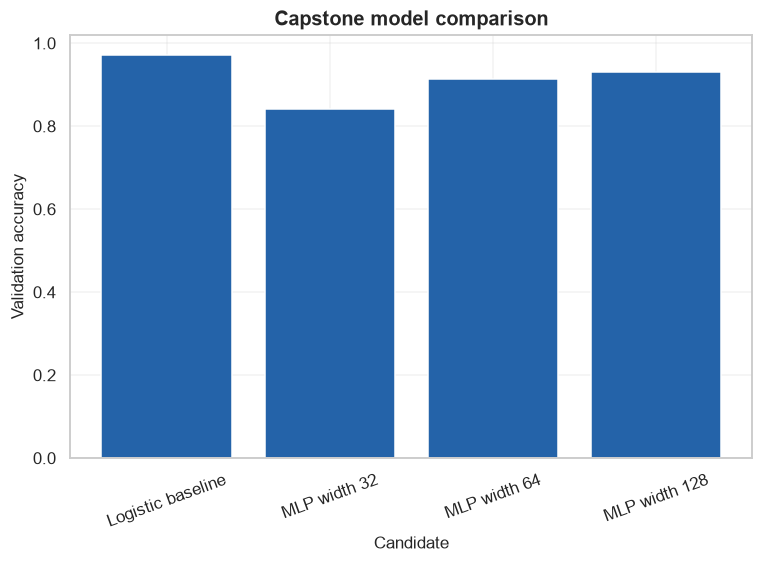

In [4]:
comparison=pd.DataFrame([
    {"model":"Logistic baseline","validation_accuracy":baseline_accuracy,"parameters":"library-managed"},
    *[{"model":f"MLP width {width}","validation_accuracy":values[3],"parameters":sum(p.numel() for p in values[0].parameters())} for width,values in candidates.items()],
])
display(comparison.round(3))
figure,axis=plt.subplots()
axis.bar(comparison["model"],comparison["validation_accuracy"],color=COURSE_COLORS["blue"])
axis.set(title="Capstone model comparison",xlabel="Candidate",ylabel="Validation accuracy")
axis.tick_params(axis="x",rotation=20)
plt.show()

## 18. Common mistakes

            - Selecting width on test accuracy
- Scaling before splitting
- Reporting only training loss
- Ignoring systematic class confusions

            ## 19. Advantages and disadvantages

            **Advantages**

            - Complete offline pipeline
- Explicit baseline and tuning
- Held-out error analysis

            **Disadvantages**

            - Small low-resolution benchmark
- No robustness or fairness audit
- One split gives limited uncertainty evidence

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why is the logistic model a useful baseline?
2. **Mathematical/hand calculation:** If 342 of 360 test images are correct, calculate accuracy.
3. **Coding/experimentation:** Repeat the final training with three seeds and report mean and range.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. It tests whether nonlinear representation learning improves on a simpler, easier-to-audit decision boundary.
2. 342/360=.95 or 95%.
3. Reset all seeds, rebuild and retrain three times, then report the three test scores, mean, and range without selecting the best run.

</details>

## Capstone delivery checklist

- **Business or real-world problem and success metric:** defined before modeling in the problem-definition section.
- **Dataset description and exploratory data analysis:** documented beside the bounded dataset preview and audit outputs.
- **Data cleaning and feature engineering:** performed after the split where fitting or target information could otherwise leak; choices are stated explicitly, including when no cleaning is required.
- **Baseline and multiple-model comparison:** a simple reference model is evaluated before more flexible candidates.
- **Hyperparameter tuning:** candidates are selected only with development or validation evidence.
- **Final evaluation and error analysis:** the frozen choice is assessed on untouched data with a task-appropriate diagnostic plot.
- **Limitations and possible improvements:** recorded with the disadvantages and interpretation so the result is not overstated.
- **Final conclusion:** the summary connects the evidence, limitations, and next steps.

## 23. Summary and key takeaways

            - Success metrics and splits precede modeling
- A deep model should earn its complexity against a baseline
- Tuning uses validation data and final claims use untouched test data
- Error analysis and limitations are part of the conclusion

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)